In [21]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

import xgboost as xgb
from xgboost import XGBClassifier

# Data splits
data = load_breast_cancer()
X, y = data.data, data.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

fit_sig = inspect.signature(XGBClassifier.fit)
init_sig = inspect.signature(XGBClassifier.__init__)

def run_config(lr, n_estimators=800, early_stopping=20, verbose=True):
    # Build constructor args
    model_kwargs = dict(
        n_estimators=n_estimators,
        learning_rate=lr,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1
    )

    # If constructor supports early_stopping_rounds, put it there
    if "early_stopping_rounds" in init_sig.parameters:
        model_kwargs["early_stopping_rounds"] = early_stopping

    model = XGBClassifier(**model_kwargs)

    # Build fit args
    fit_kwargs = dict(
        eval_set=[(X_train, y_train), (X_val, y_val)]
    )
    if "verbose" in fit_sig.parameters:
        fit_kwargs["verbose"] = verbose

    # If fit supports early_stopping_rounds, pass it there
    if "early_stopping_rounds" in fit_sig.parameters:
        fit_kwargs["early_stopping_rounds"] = early_stopping
    # Else if fit supports callbacks, use callback early stopping
    elif "callbacks" in fit_sig.parameters:
        fit_kwargs["callbacks"] = [xgb.callback.EarlyStopping(rounds=early_stopping, save_best=True)]

    model.fit(X_train, y_train, **fit_kwargs)

    # Metrics on test
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    best_it = getattr(model, "best_iteration", None)
    best_trees = (best_it + 1) if best_it is not None else None

    res = {
        "lr": lr,
        "best_trees": best_trees,
        "acc": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
        "logloss": log_loss(y_test, y_proba),
        "evals": model.evals_result()
    }
    return model, res


Train: (364, 30) Val: (91, 30) Test: (114, 30)


In [22]:
configs = [0.1, 0.2, 0.03]
runs = {}
summary = []

for lr in configs:
    model, res = run_config(lr, n_estimators=800, early_stopping=20, verbose=True)
    runs[lr] = (model, res)
    summary.append({k: res[k] for k in ["lr", "best_trees", "acc", "auc", "logloss"]})

pd.DataFrame(summary)


[0]	validation_0-logloss:0.58132	validation_1-logloss:0.58507
[1]	validation_0-logloss:0.51562	validation_1-logloss:0.52707
[2]	validation_0-logloss:0.46120	validation_1-logloss:0.47367
[3]	validation_0-logloss:0.41365	validation_1-logloss:0.43137
[4]	validation_0-logloss:0.37312	validation_1-logloss:0.39510
[5]	validation_0-logloss:0.33665	validation_1-logloss:0.36376
[6]	validation_0-logloss:0.30773	validation_1-logloss:0.33391
[7]	validation_0-logloss:0.28101	validation_1-logloss:0.31052
[8]	validation_0-logloss:0.25583	validation_1-logloss:0.28857
[9]	validation_0-logloss:0.23331	validation_1-logloss:0.26817
[10]	validation_0-logloss:0.21337	validation_1-logloss:0.25135
[11]	validation_0-logloss:0.19692	validation_1-logloss:0.23550
[12]	validation_0-logloss:0.18060	validation_1-logloss:0.22224
[13]	validation_0-logloss:0.16714	validation_1-logloss:0.21009
[14]	validation_0-logloss:0.15553	validation_1-logloss:0.19903
[15]	validation_0-logloss:0.14426	validation_1-logloss:0.18906
[1

,lr,best_trees,acc,auc,logloss
0,0.10,None,0.973684,0.993386,0.097795
1,0.20,None,0.938596,0.991733,0.116098
2,0.03,None,0.938596,0.992063,0.112027


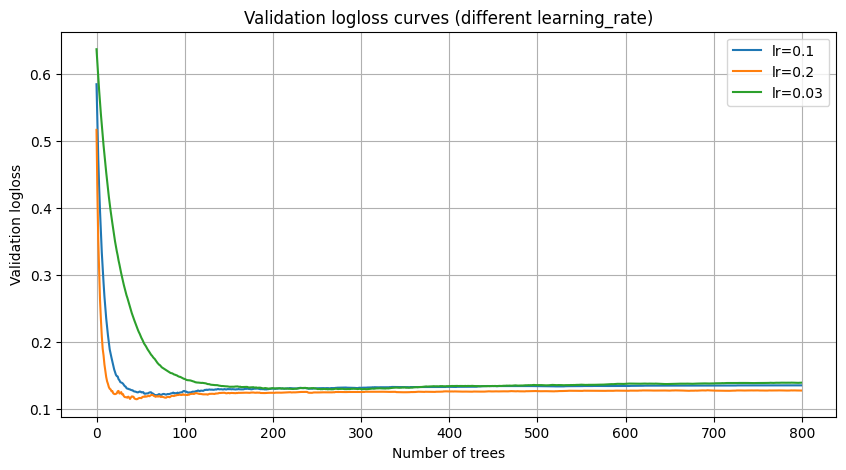

In [23]:
plt.figure(figsize=(10,5))
for lr in configs:
    evals = runs[lr][1]["evals"]
    val_logloss = evals["validation_1"]["logloss"]
    plt.plot(val_logloss, label=f"lr={lr}")
plt.xlabel("Number of trees")
plt.ylabel("Validation logloss")
plt.title("Validation logloss curves (different learning_rate)")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
model_no_val = XGBClassifier(
    n_estimators=800,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1
)
model_no_val.fit(X_train_full, y_train_full)

y_pred  = model_no_val.predict(X_test)
y_proba = model_no_val.predict_proba(X_test)[:, 1]

print("No-val accuracy:", accuracy_score(y_test, y_pred))
print("No-val AUC     :", roc_auc_score(y_test, y_proba))
print("No-val logloss :", log_loss(y_test, y_proba))


No-val accuracy: 0.9649122807017544
No-val AUC     : 0.9957010582010581
No-val logloss : 0.07964217522632304
